# Train an MLP on two moons 

A micrograd-style demo using the local `nanograd` engine and a hand-written moons dataset generator.

In [1]:
import importlib
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().resolve()
if not (repo_root / 'nanograd').exists():
    repo_root = repo_root.parent

repo_root_str = str(repo_root)
if repo_root_str in sys.path:
    sys.path.remove(repo_root_str)
sys.path.insert(0, repo_root_str)

from nanograd import engine as ng_engine
from nanograd import nn as ng_nn

importlib.reload(ng_engine)
importlib.reload(ng_nn)

Value = ng_engine.Value
MLP = ng_nn.MLP
add = ng_nn.add
mul = ng_nn.mul

In [2]:
def make_moons(n_samples=200, noise=0.1, seed=1337):
    rng = np.random.default_rng(seed)
    n_outer = n_samples // 2
    n_inner = n_samples - n_outer

    theta_outer = rng.uniform(0.0, np.pi, size=n_outer)
    theta_inner = rng.uniform(0.0, np.pi, size=n_inner)

    outer = np.c_[np.cos(theta_outer), np.sin(theta_outer)]
    inner = np.c_[1.0 - np.cos(theta_inner), 1.0 - np.sin(theta_inner) - 0.5]

    X = np.vstack([outer, inner])
    y = np.hstack([np.ones(n_outer), -np.ones(n_inner)])

    X += rng.normal(0.0, noise, size=X.shape)
    perm = rng.permutation(n_samples)
    return X[perm], y[perm]


X, y = make_moons(n_samples=100, noise=0.10, seed=1)
print('X shape:', X.shape)
print('y classes:', np.unique(y))

X shape: (100, 2)
y classes: [-1.  1.]


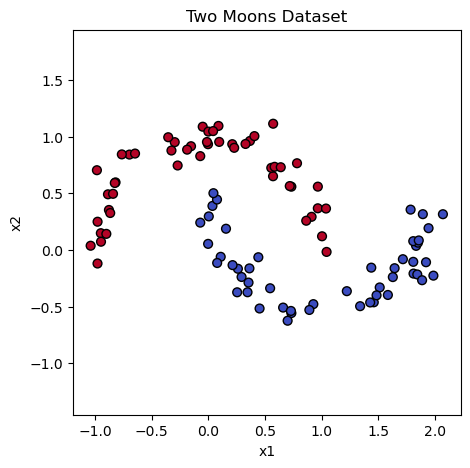

In [3]:
plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap='coolwarm', edgecolors='k')
plt.title('Two Moons Dataset')
plt.xlabel('x1')
plt.ylabel('x2')
plt.axis('equal')
plt.show()

In [ ]:
np.random.seed(1337)
model = MLP(2, [8, 1])
print(model)
print('number of parameters:', len(model.parameters()))

MLP(Layer(Neuron(nin=2, activation=tanh), Neuron(nin=2, activation=tanh), Neuron(nin=2, activation=tanh), Neuron(nin=2, activation=tanh), Neuron(nin=2, activation=tanh), Neuron(nin=2, activation=tanh), Neuron(nin=2, activation=tanh), Neuron(nin=2, activation=tanh), Neuron(nin=2, activation=tanh), Neuron(nin=2, activation=tanh), Neuron(nin=2, activation=tanh), Neuron(nin=2, activation=tanh), Neuron(nin=2, activation=tanh), Neuron(nin=2, activation=tanh), Neuron(nin=2, activation=tanh), Neuron(nin=2, activation=tanh)), Layer(Neuron(nin=16, activation=tanh), Neuron(nin=16, activation=tanh), Neuron(nin=16, activation=tanh), Neuron(nin=16, activation=tanh), Neuron(nin=16, activation=tanh), Neuron(nin=16, activation=tanh), Neuron(nin=16, activation=tanh), Neuron(nin=16, activation=tanh), Neuron(nin=16, activation=tanh), Neuron(nin=16, activation=tanh), Neuron(nin=16, activation=tanh), Neuron(nin=16, activation=tanh), Neuron(nin=16, activation=tanh), Neuron(nin=16, activation=tanh), Neuron(ni

In [5]:
def forward_scores(X_batch):
    return [model(xi.tolist()) for xi in X_batch]


def to_real_scalar(value):
    value = np.asarray(value)
    if np.iscomplexobj(value):
        value = np.real_if_close(value)
        if np.iscomplexobj(value):
            value = value.real
    return float(value)


def compute_loss_and_acc(X_batch, y_batch, alpha=0.01):
    scores = forward_scores(X_batch)

    data_loss = Value(0.0)
    for yi, si in zip(y_batch, scores):
        diff = add(si, -float(yi))
        data_loss = add(data_loss, mul(diff, diff))
    data_loss = mul(data_loss, 1.0 / len(scores))

    reg = Value(0.0)
    for p in model.parameters():
        reg = add(reg, mul(p, p))
    reg_loss = mul(alpha, reg)

    total_loss = add(data_loss, reg_loss)

    y_pred = np.array([1.0 if to_real_scalar(s.data) > 0 else -1.0 for s in scores])
    acc = (y_pred == y_batch).mean()
    return total_loss, acc

In [ ]:
steps = 10
batch_size = len(X) # full batch gradient descent
rng = np.random.default_rng(42)

history_loss = []
history_acc = []

for k in range(steps):
    idx = rng.choice(len(X), size=batch_size, replace=False)
    Xb, yb = X[idx], y[idx]

    total_loss, acc = compute_loss_and_acc(Xb, yb)

    model.zero_grad()
    total_loss.backward()

    lr = 0.1 * (0.5 ** (k / 100.0))  # exponential decay
    for p in model.parameters():
        p.data += -lr * p.grad

    loss_value = to_real_scalar(total_loss.data)
    history_loss.append(loss_value)
    history_acc.append(acc)

    if k % 20 == 0 or k == steps - 1:
        print(f'step {k:03d}: loss={loss_value:.4f}, acc={acc * 100:.1f}%')

    if acc > 0.95:
        print(f'Accuracy > 95% reached at step {k:03d}. Stopping training.')
        break

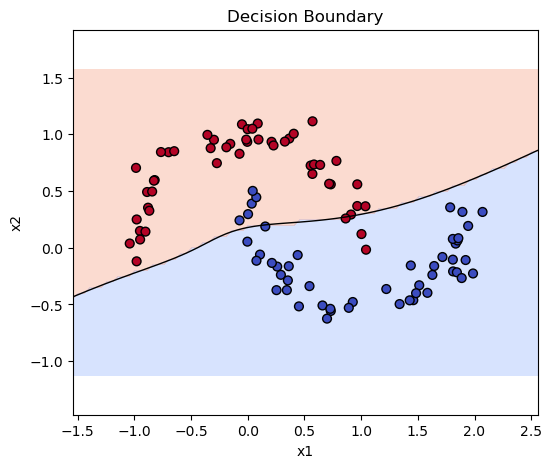

In [ ]:
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
h = 0.05
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]

with np.errstate(all='ignore'):
    Z = np.array([to_real_scalar(model(pt.tolist()).data) for pt in grid])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z > 0, alpha=0.35, cmap='coolwarm')
plt.contour(xx, yy, Z, levels=[0.0], colors='k', linewidths=1)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap='coolwarm', edgecolors='k')
plt.title('Decision Boundary')
plt.xlabel('x1')
plt.ylabel('x2')
plt.axis('equal')
plt.show()